In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.4 MB/s eta 0:00:00


In [2]:
from Bio import SeqIO

In [3]:
import requests
from Bio import SeqIO
from io import StringIO

url="https://raw.githubusercontent.com/menekduru/Cytochrome-C-Phylogenetic-Analysis/main/data/cytochrome_c_sequences.fasta"

response = requests.get(url)
response.raise_for_status()

fasta_data = StringIO(response.text)
sequences = list(SeqIO.parse(fasta_data, "fasta"))
print("Number of sequences:", len(sequences))

for seq in sequences:
    print(seq.id, len(seq.seq))

Number of sequences: 6
NP_061820.1 105
NP_001065289.1 105
NP_001183974.1 105
NP_001157486.2 105
NP_001039526.1 105
NP_001072946.1 105


In [4]:
species = {
    "NP_061820.1": "Homo_sapiens",
    "NP_001065289.1": "Pan_troglodytes",
    "NP_001183974.1": "Canis_lupus_familiaris",
    "NP_001157486.2": "Equus_caballus",
    "NP_001039526.1": "Bos_taurus",
    "NP_001072946.1": "Gallus_gallus"
}

for seq in sequences:
    print(species[seq.id], ":", len(seq.seq), "aa")

Homo_sapiens : 105 aa
Pan_troglodytes : 105 aa
Canis_lupus_familiaris : 105 aa
Equus_caballus : 105 aa
Bos_taurus : 105 aa
Gallus_gallus : 105 aa


In [ ]:
!apt-get update -qq
!apt-get install -y mafft -qq

In [6]:
from Bio import SeqIO
input_file = "cytochrome_c_sequences.fasta"
SeqIO.write(sequences, input_file, "fasta")

6

In [ ]:
!mafft --auto cytochrome_c_sequences.fasta > cytochrome_c_aligned.fasta

In [8]:
from Bio import AlignIO
alignment = AlignIO.read("cytochrome_c_aligned.fasta", "fasta")
aligned_sequences = list(alignment)
print(alignment)

Alignment with 6 rows and 105 columns
MGDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNLHGLFGRKTGQA...TNE NP_061820.1
MGDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNLHGLFGRKTGQA...TNE NP_001065289.1
MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQA...TKE NP_001183974.1
MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQA...TNE NP_001157486.2
MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQA...TNE NP_001039526.1
MGDIEKGKKIFVQKCSQCHTVEKGGKHKTGPNLHGLFGRKTGQA...TSK NP_001072946.1


In [9]:
from collections import Counter

alignment_length = alignment.get_alignment_length()
fully_conserved =[]

for i in range(alignment_length):
    column = alignment[:, i]
    residues = [aa for aa in column if aa != "-"]

    if residues and len(set(residues)) ==1:
        fully_conserved.append(i+1)

print("Alignment length:", alignment_length)
print("Fully conserved positions:", len(fully_conserved))
print("Positions:", fully_conserved)

Alignment length: 105
Fully conserved positions: 87
Positions: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 49, 50, 52, 53, 54, 55, 56, 57, 58, 60, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 91, 92, 94, 95, 96, 97, 98, 99, 100, 102, 103]


In [10]:
variable_positions = []

for i in range(alignment_length):
    column = alignment[:, i]
    residues = [aa for aa in column if aa != "-"]

    if len(set(residues)) > 1:
        variable_positions.append(i+1)

print("Variable positions:", len(variable_positions))
print("Positions:", variable_positions)

Variable positions: 18
Positions: [4, 12, 13, 16, 45, 47, 48, 51, 59, 61, 63, 84, 89, 90, 93, 101, 104, 105]


In [11]:
from Bio import AlignIO
import pandas as pd
import numpy as np

alignment = AlignIO.read("cytochrome_c_aligned.fasta", "fasta")

species = {
    "NP_061820.1": "Homo_sapiens",
    "NP_001065289.1": "Pan_troglodytes",
    "NP_001183974.1": "Canis_lupus_familiaris",
    "NP_001157486.2": "Equus_caballus",
    "NP_001039526.1": "Bos_taurus",
    "NP_001072946.1": "Gallus_gallus"
}

names = [species[record.id] for record in alignment]

aligned_dict = {
    species[record.id]: str(record.seq)
    for record in alignment
}

identity_matrix = pd.DataFrame(
    np.zeros((len(names), len(names))),
    index=names,
    columns=names
)

for name1 in names:
    for name2 in names:

        seq1 = aligned_dict[name1]
        seq2 = aligned_dict[name2]

        matches = 0
        comparable = 0

        for a, b in zip(seq1, seq2):
            if a != "-" and b != "-":
                comparable += 1

                if a == b:
                    matches += 1

        identity = (matches / comparable) * 100

        identity_matrix.loc[name1, name2] = identity

print("Pairwise Sequence Identity (%)")
display(identity_matrix.round(2))

Pairwise Sequence Identity (%)


,Homo_sapiens,Pan_troglodytes,Canis_lupus_familiaris,Equus_caballus,Bos_taurus,Gallus_gallus
Homo_sapiens,100.00,100.00,89.52,88.57,90.48,87.62
Pan_troglodytes,100.00,100.00,89.52,88.57,90.48,87.62
Canis_lupus_familiaris,89.52,89.52,100.00,94.29,97.14,90.48
Equus_caballus,88.57,88.57,94.29,100.00,97.14,89.52
Bos_taurus,90.48,90.48,97.14,97.14,100.00,91.43
Gallus_gallus,87.62,87.62,90.48,89.52,91.43,100.00


In [12]:
distance_matrix = 100 - identity_matrix
print("Pairwise Distance Matrix")
display(distance_matrix.round(2))

Pairwise Distance Matrix


,Homo_sapiens,Pan_troglodytes,Canis_lupus_familiaris,Equus_caballus,Bos_taurus,Gallus_gallus
Homo_sapiens,0.00,0.00,10.48,11.43,9.52,12.38
Pan_troglodytes,0.00,0.00,10.48,11.43,9.52,12.38
Canis_lupus_familiaris,10.48,10.48,0.00,5.71,2.86,9.52
Equus_caballus,11.43,11.43,5.71,0.00,2.86,10.48
Bos_taurus,9.52,9.52,2.86,2.86,0.00,8.57
Gallus_gallus,12.38,12.38,9.52,10.48,8.57,0.00


In [13]:
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor

names = list(distance_matrix.index)
matrix = []

for i in range(len(names)):
    row = []
    for j in range(i+1):
        row.append(float(distance_matrix.iloc[i, j]))
    matrix.append(row)

dm = DistanceMatrix(names, matrix)
constructor = DistanceTreeConstructor()
tree = constructor.nj(dm)

print(tree)

Tree(rooted=False)
    Clade(branch_length=0, name='Inner4')
        Clade(branch_length=0.7142857142857171, name='Inner3')
            Clade(branch_length=1.666666666666659, name='Inner2')
                Clade(branch_length=5.714285714285713, name='Gallus_gallus')
                Clade(branch_length=6.666666666666667, name='Inner1')
                    Clade(branch_length=0.0, name='Homo_sapiens')
                    Clade(branch_length=0.0, name='Pan_troglodytes')
            Clade(branch_length=2.142857142857144, name='Canis_lupus_familiaris')
        Clade(branch_length=2.619047619047622, name='Equus_caballus')
        Clade(branch_length=0.23809523809523903, name='Bos_taurus')


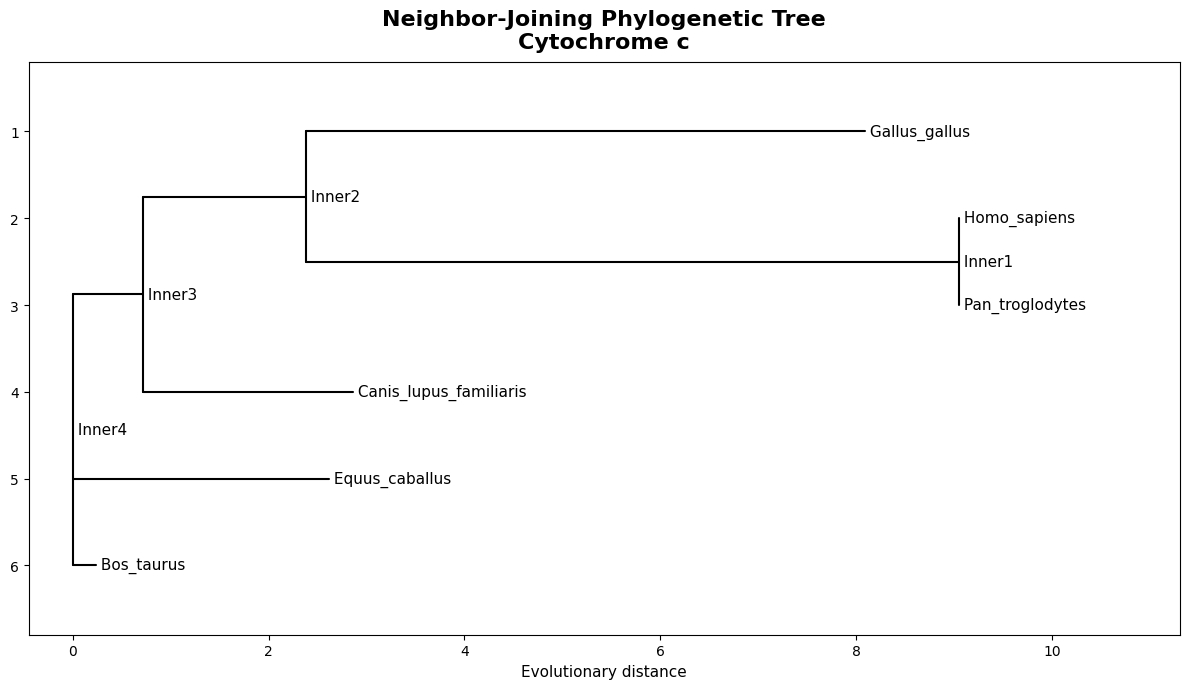

In [15]:
import matplotlib.pyplot as plt
from Bio import Phylo

tree.rooted = False

fig = plt.figure(figsize=(12, 7))

axes = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree,
    axes=axes,
    do_show=False
)

axes.set_title(
    "Neighbor-Joining Phylogenetic Tree\nCytochrome c",
    fontsize=16,
    fontweight="bold",
    pad=10
)

axes.set_xlabel("Evolutionary distance", fontsize=11)
axes.set_ylabel("")

for text in axes.texts:
    text.set_fontsize(11)

plt.tight_layout()
plt.show()

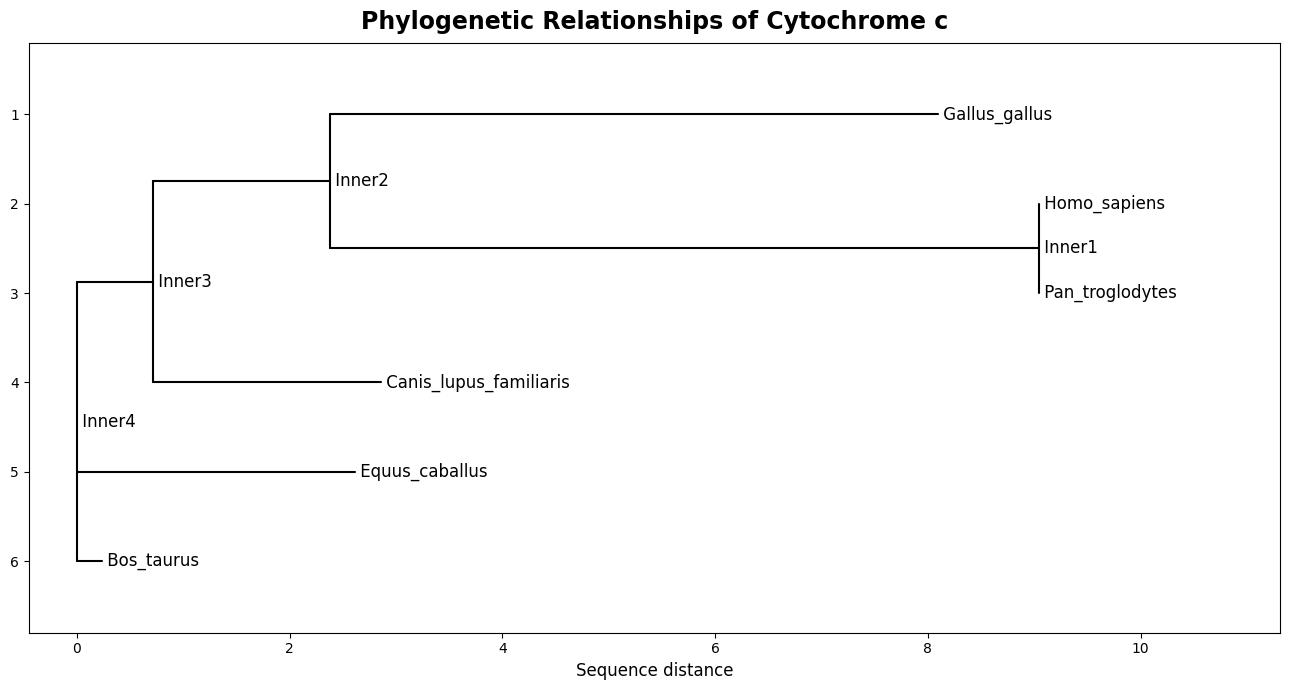

In [16]:
import matplotlib.pyplot as plt
from Bio import Phylo

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False
)

ax.set_title(
    "Phylogenetic Relationships of Cytochrome c",
    fontsize=17,
    fontweight="bold",
    pad=10
)

ax.set_xlabel(
    "Sequence distance",
    fontsize=12
)

ax.set_ylabel("")

for text in ax.texts:
    text.set_fontsize(12)

ax.margins(x=0.15)

plt.tight_layout()
plt.savefig(
    "cytochrome_c_phylogenetic_tree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
for clade in tree.find_clades():
    print(
        clade.name,
        "branch length:",
        clade.branch_length
    )

Inner4 branch length: 0
Inner3 branch length: 0.7142857142857171
Inner2 branch length: 1.666666666666659
Gallus_gallus branch length: 5.714285714285713
Inner1 branch length: 6.666666666666667
Homo_sapiens branch length: 0.0
Pan_troglodytes branch length: 0.0
Canis_lupus_familiaris branch length: 2.142857142857144
Equus_caballus branch length: 2.619047619047622
Bos_taurus branch length: 0.23809523809523903


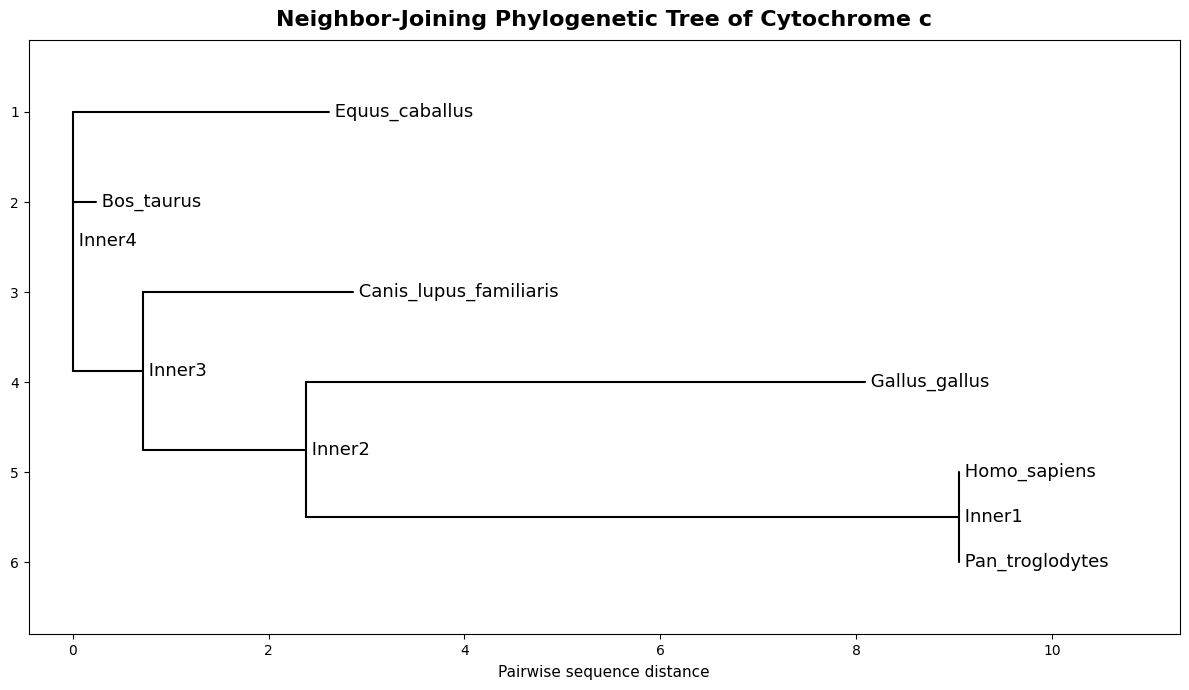

In [18]:
tree.ladderize()

fig, ax = plt.subplots(figsize=(12, 7))

Phylo.draw(
    tree,
    axes=ax,
    do_show=False
)

ax.set_title(
    "Neighbor-Joining Phylogenetic Tree of Cytochrome c",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Pairwise sequence distance", fontsize=11, labelpad=5)
ax.set_ylabel("")

for text in ax.texts:
    text.set_fontsize(13)

plt.tight_layout()
plt.savefig(
    "cytochrome_c_phylogenetic_tree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

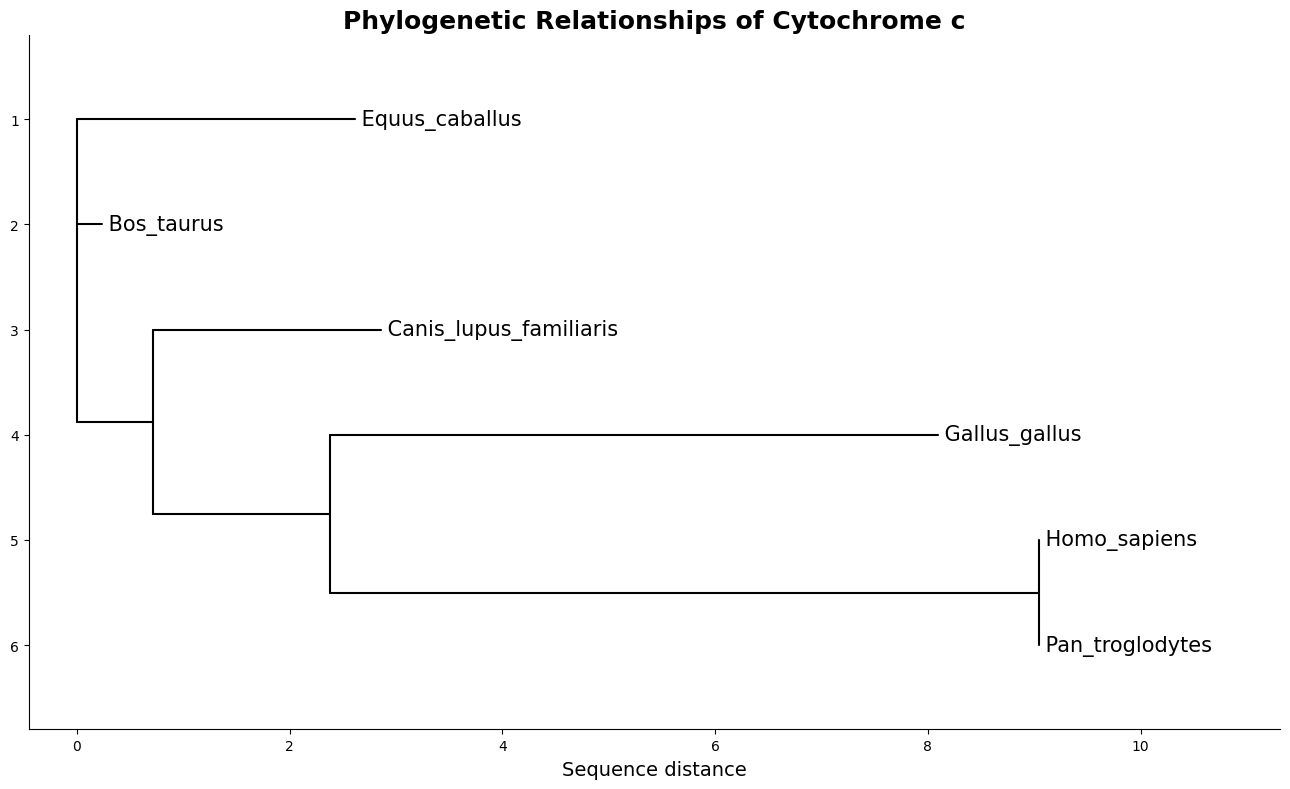

In [19]:
import matplotlib.pyplot as plt
from Bio import Phylo

for clade in tree.find_clades():
    if clade.name and clade.name.startswith("Inner"):
        clade.name = None

tree.ladderize()

fig, ax = plt.subplots(figsize=(13, 8))

Phylo.draw(
    tree,
    axes=ax,
    do_show=False
)

ax.set_title(
    "Phylogenetic Relationships of Cytochrome c",
    fontsize=18,
    fontweight="bold",
    pad=5
)

ax.set_xlabel(
    "Sequence distance",
    fontsize=14,
    labelpad=5
)

ax.set_ylabel("")

for text in ax.texts:
    text.set_fontsize(15)

ax.margins(x=0.15, y=0.05)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    "cytochrome_c_phylogenetic_tree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [20]:
import random
from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord

In [21]:
def bootstrap_alignment(alignment):

    n_sites = alignment.get_alignment_length()

    sampled_columns = [
        random.choice(range(n_sites))
        for _ in range(n_sites)
    ]

    new_records = []

    for record in alignment:
        new_sequence = "".join(
            record.seq[i]
            for i in sampled_columns
        )
        new_records.append(
            SeqRecord(
                new_sequence,
                id=record.id,
                description=""
            )
        )

    return MultipleSeqAlignment(new_records)

In [22]:
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor

In [23]:
def alignment_to_distance(alignment):
    names = [record.id for record in alignment]
    matrix = []

    for i in range(len(names)):
        row = []

        for j in range(i + 1):
            seq1 = str(alignment[i].seq)
            seq2 = str(alignment[j].seq)

            matches = 0
            comparable = 0

            for a, b in zip(seq1, seq2):
                if a != "-" and b != "-":
                    comparable += 1
                    if a == b:
                        matches += 1

            distance = 100 - (matches / comparable * 100)
            row.append(distance)
        matrix.append(row)

    return DistanceMatrix(names, matrix)

In [24]:
def bootstrap_alignment(alignment):

    n_sites = alignment.get_alignment_length()

    sampled_columns = [
        random.randrange(n_sites)
        for _ in range(n_sites)]

    new_records = []

    for record in alignment:

        new_sequence = "".join(
            str(record.seq[i])
            for i in sampled_columns)

        new_records.append(
            record.__class__(
                Seq(new_sequence),
                id=record.id,
                description=""))

    return MultipleSeqAlignment(new_records)

In [25]:
from Bio.Seq import Seq
from Bio.Align import MultipleSeqAlignment

In [26]:
bootstrap_trees = []

for i in range(1000):
    boot_alignment = bootstrap_alignment(alignment)
    boot_dm = alignment_to_distance(boot_alignment)
    boot_tree = constructor.nj(boot_dm)
    bootstrap_trees.append(boot_tree)
print("Bootstrap trees generated:", len(bootstrap_trees))

Bootstrap trees generated: 1000


In [27]:
def get_clades(tree):
    clades = set()

    terminals = {
        terminal.name
        for terminal in tree.get_terminals()
    }

    for clade in tree.get_nonterminals():
        members = frozenset(
            terminal.name
            for terminal in clade.get_terminals()
        )

        if 1 < len(members) < len(terminals):
            clades.add(members)

    return clades

In [28]:
original_clades = get_clades(tree)

print("Original tree clades:")

for clade in original_clades:
    print(sorted(clade))

Original tree clades:
['Canis_lupus_familiaris', 'Gallus_gallus', 'Homo_sapiens', 'Pan_troglodytes']
['Gallus_gallus', 'Homo_sapiens', 'Pan_troglodytes']
['Homo_sapiens', 'Pan_troglodytes']


In [29]:
name_map = {
    "NP_061820.1": "Homo_sapiens",
    "NP_001065289.1": "Pan_troglodytes",
    "NP_001183974.1": "Canis_lupus_familiaris",
    "NP_001157486.2": "Equus_caballus",
    "NP_001039526.1": "Bos_taurus",
    "NP_001072946.1": "Gallus_gallus"
}

In [30]:
for boot_tree in bootstrap_trees:
    for terminal in boot_tree.get_terminals():
        terminal.name = name_map[terminal.name]

In [31]:
for clade in get_clades(bootstrap_trees[0]):
    print(sorted(clade))

['Equus_caballus', 'Gallus_gallus', 'Homo_sapiens', 'Pan_troglodytes']
['Gallus_gallus', 'Homo_sapiens', 'Pan_troglodytes']
['Homo_sapiens', 'Pan_troglodytes']


In [32]:
bootstrap_support = {}

for clade in original_clades:
    count = 0
    for boot_tree in bootstrap_trees:
        boot_clades = get_clades(boot_tree)
        if clade in boot_clades:
            count += 1

    support = (count / len(bootstrap_trees)) * 100
    bootstrap_support[clade] = support

print("Bootstrap support:")
print()

for clade, support in bootstrap_support.items():
    print(
        sorted(clade),
        "→",
        round(support, 1),
        "%")

Bootstrap support:

['Canis_lupus_familiaris', 'Gallus_gallus', 'Homo_sapiens', 'Pan_troglodytes'] → 42.8 %
['Gallus_gallus', 'Homo_sapiens', 'Pan_troglodytes'] → 61.0 %
['Homo_sapiens', 'Pan_troglodytes'] → 100.0 %


In [33]:
parents = {}

for parent in tree.find_clades(order="preorder"):
    for child in parent.clades:
        parents[child] = parent

In [34]:
y_positions = {}

terminals = tree.get_terminals()

for i, clade in enumerate(terminals):
    y_positions[clade] = i * 1.5


def get_y(clade):
    if clade in y_positions:
        return y_positions[clade]

    child_y = [get_y(child) for child in clade.clades]

    y_positions[clade] = sum(child_y) / len(child_y)

    return y_positions[clade]


for clade in tree.find_clades(order="postorder"):
    get_y(clade)

In [35]:
x_positions = {tree.root: 0}


def get_x(clade):
    if clade in x_positions:
        return x_positions[clade]

    parent = parents[clade]
    branch = clade.branch_length or 0

    x_positions[clade] = get_x(parent) + branch

    return x_positions[clade]


for clade in tree.find_clades(order="preorder"):
    get_x(clade)

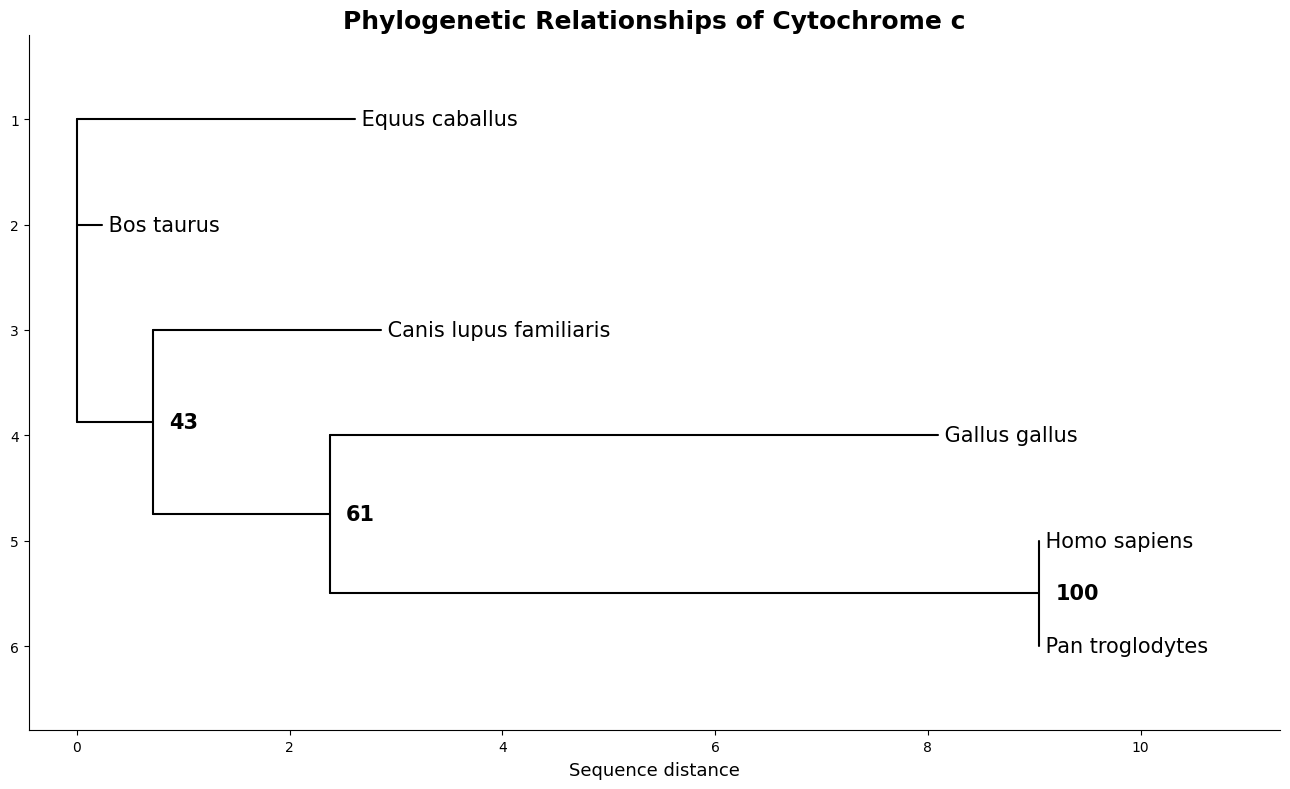

In [56]:
import matplotlib.pyplot as plt
from Bio import Phylo

tree.ladderize()

fig, ax = plt.subplots(figsize=(13, 8))

def label_func(clade):
    if clade.is_terminal():
        return clade.name.replace("_", " ")
    return None

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    label_func=label_func,
    show_confidence=False)


x_positions = tree.depths()

y_positions = {}

terminals = tree.get_terminals()
n_terminals = len(terminals)

for i, terminal in enumerate(reversed(terminals)):
    y_positions[terminal] = n_terminals - i


def calculate_y(clade):

    if clade in y_positions:
        return y_positions[clade]

    child_y = [
        calculate_y(child)
        for child in clade.clades]

    y_positions[clade] = (
        child_y[0] + child_y[-1]) / 2

    return y_positions[clade]


calculate_y(tree.root)


for clade, support in bootstrap_support.items():

    for tree_clade in tree.get_nonterminals():

        members = frozenset(
            terminal.name
            for terminal in tree_clade.get_terminals())

        if members == clade:

            x = x_positions[tree_clade]
            y = y_positions[tree_clade]

            ax.text(
                x + 0.15,
                y + 0.09,
                f"{support:.0f}",
                fontsize=10,
                fontweight="bold",
                ha="left",
                va="bottom")
            break


ax.set_title(
    "Phylogenetic Relationships of Cytochrome c",
    fontsize=18,
    fontweight="bold",
    pad=5)

ax.set_xlabel(
    "Sequence distance",
    fontsize=13,
    labelpad=5)

ax.set_ylabel("")

for text in ax.texts:
    text.set_fontsize(15)

ax.margins(x=0.15, y=0.05)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "cytochrome_c_phylogenetic_tree_bootstrap.png",
    dpi=300,
    bbox_inches="tight")

plt.show()